# Workflow for Quadratic Equation

In [ ]:
"""
                                                    --> no_real_roots  -->
START  --> Show_Equation  --> Calculate_Discrimint  --> real_roots     --> END
                                                    --> repeated_roots --> 
"""

In [4]:
from langgraph.graph import StateGraph , START , END
from typing import TypedDict , Literal

In [12]:
class QuadraticState(TypedDict):
    a: int
    b: int
    c: int
    equation: str
    discrimint: float
    result: str    

In [ ]:
def show_equation(state: QuadraticState) -> QuadraticState:
    a = state['a']
    b = state['b']
    c = state['c']
    equation = f"{a}x**2{b}x{c}"
    return {"equation":equation}

def calculate_discriminant(state: QuadraticState) -> QuadraticState:
    discrimint = state["b"]**2 - (4*state['a']*state['c'])
    return {"discrimint":discrimint}

In [19]:
def no_real_roots(state: QuadraticState) -> QuadraticState:
    result = f"No real roots fond"
    return {"result":result}

def real_roots(state: QuadraticState) -> QuadraticState:
    root1 = (-state['b'] + state['discrimint']**0.5)/(2*state['a'])
    root2 = (-state['b'] - state['discrimint']**0.5)/(2*state['a'])
    result = f"The roots are {root1} and {root2}"
    return {"result":result}

def repeated_real_roots(state: QuadraticState) -> QuadraticState:
    root = (-state['b'])/(2*state['a'])
    result = f"Only Repeated root is {root}"
    return {"result":result}


In [20]:
def check_condition(state: QuadraticState) -> Literal["real_roots","no_real_roots","repeated_real_roots"]:
    if state["discrimint"] > 0:
        return "real_roots"
    elif state["discrimint"] < 0:
        return "no_real_roots"
    else:
        return "repeated_real_roots"

In [21]:
graph = StateGraph(QuadraticState)

graph.add_node("show_equation", show_equation)
graph.add_node("calculate_discriminant", calculate_discriminant)

graph.add_node("no_real_roots",no_real_roots)
graph.add_node("real_roots",real_roots)
graph.add_node("repeated_real_roots",repeated_real_roots)

graph.add_edge(START,"show_equation")
graph.add_edge("show_equation","calculate_discriminant")
graph.add_conditional_edges("calculate_discriminant",check_condition)

graph.add_edge("real_roots",END)
graph.add_edge("no_real_roots",END)
graph.add_edge("repeated_real_roots",END)

workflow = graph.compile()

In [27]:
intial_state = {"a" : 2,"b" : 4,"c" : 2}

final_state = workflow.invoke(intial_state)

print(final_state)

{'a': 2, 'b': 4, 'c': 2, 'equation': '2x**24x2', 'discrimint': 0, 'result': 'Only Repeated root is -1.0'}


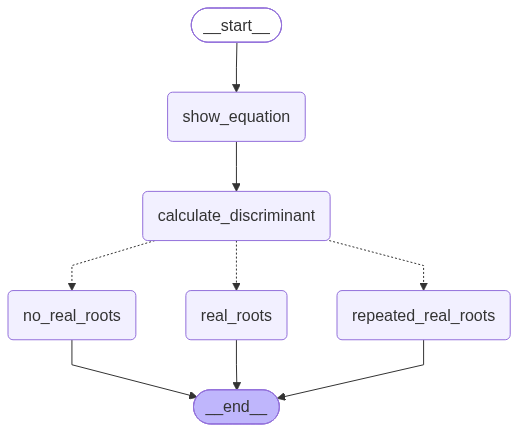

In [23]:
workflow

# Workflow for Sentiment Analysis

In [ ]:
"""
                                 -->                                        positive_response (LLM)
START  --> find_sentiment (LLM)  --> run_diagnosis (LLM) (Conditional)  --> negative_response (LLM)   --> END
"""

In [26]:
from langgraph.graph import StateGraph , START , END
from langchain_openai import ChatOpenAI
from typing import TypedDict , Literal
from dotenv import load_dotenv
from pydantic import BaseModel , Field

In [27]:
load_dotenv()
model = ChatOpenAI()

In [44]:
class SentimentSchema(BaseModel):
    sentiment: Literal["positive", "negative"] = Field(description='Sentiment of the review')

In [45]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX", "Performance", "Bug", "Support", "Other"] = Field(description='The category of issue mentioned in the review')
    tone: Literal["angry", "frustrated", "disappointed", "calm"] = Field(description='The emotional tone expressed by the user')
    urgency: Literal["low", "medium", "high"] = Field(description='How urgent or critical the issue appears to be')

In [48]:
structured_model = model.with_structured_output(SentimentSchema)
structured_model2 = model.with_structured_output(DiagnosisSchema)

c:\Users\DELL\Desktop\Agentic-AI-Using-LangGraph\myagentvenv\Lib\site-packages\langchain_openai\chat_models\base.py:2493: UserWarning: Cannot use method='json_schema' with model gpt-3.5-turbo since it doesn't support OpenAI's Structured Output API. You can see supported models here: https://platform.openai.com/docs/guides/structured-outputs#supported-models. To fix this warning, set `method='function_calling'. Overriding to method='function_calling'.
  warnings.warn(


In [49]:
class ReviewState(TypedDict):

    review: str
    sentiment: Literal["positive", "negative"]
    diagnosis: dict
    response: str

In [ ]:
def find_sentiment(state: ReviewState):
    prompt = f'For the following review find out the sentiment \n {state["review"]}'
    sentiment = structured_model.invoke(prompt).sentiment
    return {'sentiment': sentiment}


def check_sentiment(state: ReviewState) -> Literal["positive_response", "run_diagnosis"]:
    if state['sentiment'] == 'positive':
        return 'positive_response'
    else:
        return 'run_diagnosis'
    
    
def positive_response(state: ReviewState):
    prompt = f"""Write a warm thank-you message in response to this review:
    \n\n\"{state['review']}\"\n
Also, kindly ask the user to leave feedback on our website."""
    response = model.invoke(prompt).content
    return {'response': response}


def run_diagnosis(state: ReviewState):
    prompt = f"""Diagnose this negative review:\n\n{state['review']}\n"
    "Return issue_type, tone, and urgency.
"""
    response = structured_model2.invoke(prompt)
    return {'diagnosis': response.model_dump()}


def negative_response(state: ReviewState):
    diagnosis = state['diagnosis']
    prompt = f"""You are a support assistant.
The user had a '{diagnosis['issue_type']}' issue, sounded '{diagnosis['tone']}', and marked urgency as '{diagnosis['urgency']}'.
Write an empathetic, helpful resolution message.
"""
    response = model.invoke(prompt).content
    return {'response': response}

In [51]:
graph = StateGraph(ReviewState)

graph.add_node('find_sentiment', find_sentiment)
graph.add_node('positive_response', positive_response)
graph.add_node('run_diagnosis', run_diagnosis)
graph.add_node('negative_response', negative_response)

graph.add_edge(START, 'find_sentiment')

graph.add_conditional_edges('find_sentiment', check_sentiment)

graph.add_edge('positive_response', END)

graph.add_edge('run_diagnosis', 'negative_response')
graph.add_edge('negative_response', END)

workflow = graph.compile()

In [52]:
intial_state={
    'review': "I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality."
}
final_state  = workflow.invoke(intial_state)
print(final_state)


{'review': 'I’ve been trying to log in for over an hour now, and the app keeps freezing on the authentication screen. I even tried reinstalling it, but no luck. This kind of bug is unacceptable, especially when it affects basic functionality.', 'sentiment': 'negative', 'diagnosis': {'issue_type': 'Bug', 'tone': 'frustrated', 'urgency': 'high'}, 'response': "I'm sorry to hear that you're experiencing a bug issue and feeling frustrated. I understand how frustrating technical issues can be, especially when they're impacting your work or tasks. \n\nI want to assure you that I am here to help you resolve this issue as quickly as possible. Can you please provide me with more details about the bug you are encountering so that I can better assist you? \n\nYour comfort and satisfaction are important to us, and we are committed to finding a solution to this problem promptly. Thank you for bringing this to our attention, and we will do our best to address it promptly."}


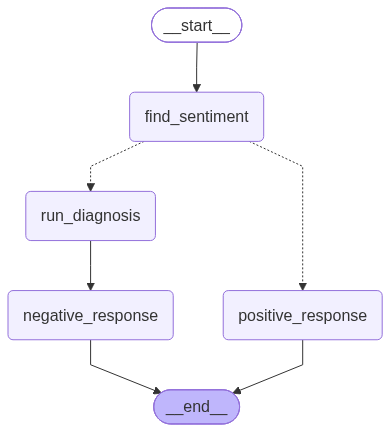

In [53]:
workflow